In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pylab as plt
plt.style.use('ggplot') # for much professional loooking ..from R

In [ ]:
#load daatset
data =pd.read_csv("heart.csv")
data.head(3)
# time is taken on remand or followup by doctor

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,DEATH_EVENT_S
0,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.9,130.0,1.0,0.0,4.0,1.0,dead
1,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.1,136.0,1.0,0.0,6.0,1.0,dead
2,65.0,0.0,146.0,0.0,20.0,0.0,162000.00,1.3,129.0,1.0,1.0,7.0,1.0,dead


In [5]:
data.shape
data.columns = [name.lower() for name in data.columns] #list comprehension to use lowercase so we can confidenttly write column name without worrying
data.head(2)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event,death_event_s
0,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.9,130.0,1.0,0.0,4.0,1.0,dead
1,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.1,136.0,1.0,0.0,6.0,1.0,dead


First, I checked the shape of the dataset to understand its size. I converted all column names to lowercase for consistency and easier coding. Then I looked at the first few rows to verify data types and values, ensuring everything loaded correctly before analysis.

In [6]:
#cheking duplicates
row_dupli=data.duplicated().sum()
print(f"Duplicated row:{row_dupli}")

#data.duplicated()
data[data.duplicated()]

Duplicated row:10


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event,death_event_s
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.9,130.0,1.0,0.0,4.0,1.0,dead
8,75.0,0.0,582.0,0.0,20.0,1.0,265000.00,1.9,130.0,1.0,0.0,4.0,1.0,dead
9,55.0,0.0,7861.0,0.0,38.0,0.0,263358.03,1.1,136.0,1.0,0.0,6.0,1.0,dead
10,65.0,0.0,146.0,0.0,20.0,0.0,162000.00,1.3,129.0,1.0,1.0,7.0,1.0,dead
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#missing value analysis step
data.isna().sum()

age                         7
anaemia                     7
creatinine_phosphokinase    7
diabetes                    7
ejection_fraction           8
high_blood_pressure         7
platelets                   8
serum_creatinine            7
serum_sodium                8
sex                         7
smoking                     7
time                        7
death_event                 7
death_event_s               8
dtype: int64

In [8]:
nan_by_col=data.isna().sum().reset_index() #reset_index() turns the result into a nice table (DataFrame) instead of a Series
nan_by_col.columns= ["columns","missing"]# naming the columns 
nan_by_col["valid"]=[len(data) -c for c in nan_by_col.missing]# .columns and .missing is how pandas stores the column names
nan_by_col

,columns,missing,valid
0,age,7,304
1,anaemia,7,304
2,creatinine_phosphokinase,7,304
3,diabetes,7,304
4,ejection_fraction,8,303
5,high_blood_pressure,7,304
6,platelets,8,303
7,serum_creatinine,7,304
8,serum_sodium,8,303
9,sex,7,304


How many missing and non-missing values does each column have lets see in barplot


Text(0, 0.5, 'Nr.rows')

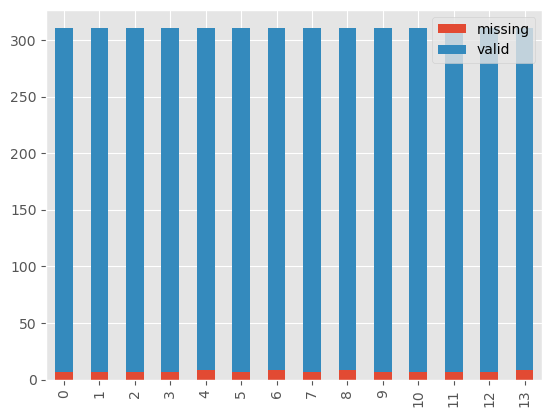

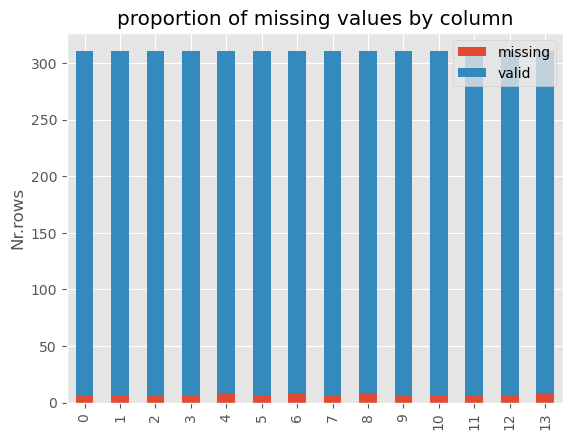

In [9]:
nan_by_col=data.isna().sum().reset_index()
nan_by_col.columns= ["columns","missing"]
nan_by_col["valid"]=[len(data) -c for c in nan_by_col.missing]
nan_by_col.plot(kind='bar',stacked=True) #If stacked=False (default), pandas will draw bars for each column side by side. stacked=True → stack values on top of each other in the same bar.
g= nan_by_col.plot(kind="bar", stacked=True)
g.set_title("proportion of missing values by column")
g.set_ylabel("Nr.rows")

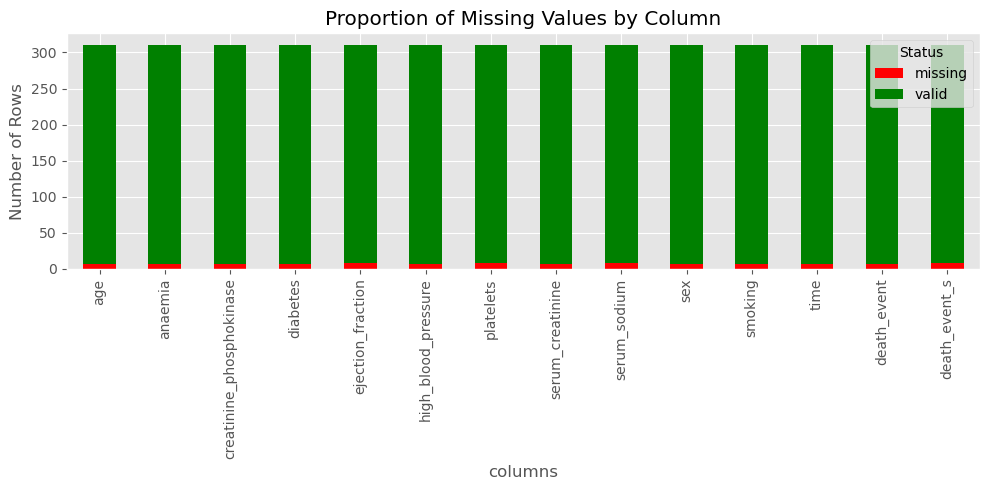

In [ ]:
nan_by_col = data.isna().sum().reset_index()
nan_by_col.columns = ["columns", "missing"]
nan_by_col["valid"] = len(data) - nan_by_col["missing"]

# Set index to column names
nan_by_col = nan_by_col.set_index("columns")

# Plot stacked bar
ax = nan_by_col[["missing", "valid"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    color=["red", "green"]
)

ax.set_title("Proportion of Missing Values by Column")
ax.set_ylabel("Number of Rows")
ax.legend(title="Status")
plt.tight_layout() #adjusts spacing so labels & title don’t overlap.
plt.show()


In [11]:
nan_by_col

,missing,valid
columns,,
age,7,304
anaemia,7,304
creatinine_phosphokinase,7,304
diabetes,7,304
ejection_fraction,8,303
high_blood_pressure,7,304
platelets,8,303
serum_creatinine,7,304
serum_sodium,8,303


In [ ]:
total_nan = data.isna().sum().sum()
print(f"Number of toal cells with missing values: {total_nan}")

Number of toal cells with missing values: 102


No. rows with as least one NA: 8
No. of rows full NA: 7


<Axes: >

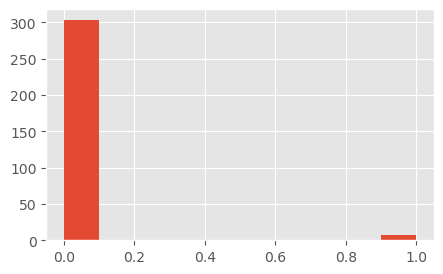

In [ ]:
# cheking missing value row wise
nr_rows_min_one_na=data.isna().any(axis=1).sum() #axis=1 → means check row-wise .any() → means “Is there at least one True (missing value) in this row?”
print(f"No. rows with as least one NA: {nr_rows_min_one_na}")

nr_rows_full_na = data.isna().all(axis=1).sum()
print(f"No. of rows full NA: {nr_rows_full_na}")
      
perc_na_per_row= data.isna().sum(axis=1)/len(data.columns)# fiest add how many missing values a person has and divided by total ...which is column
perc_na_per_row.hist(figsize=(5,3))  

this histogram shows most patients have  percent of missing values and few have 90 to 100 percent of misssing data

In [ ]:
data =data.dropna().copy()# removes those rows which have nan in  any single mising value
data.shape

data =data.drop_duplicates()
data.shape

(299, 14)

In [15]:
data.dtypes

age                         float64
anaemia                     float64
creatinine_phosphokinase    float64
diabetes                    float64
ejection_fraction           float64
high_blood_pressure         float64
platelets                   float64
serum_creatinine            float64
serum_sodium                float64
sex                         float64
smoking                     float64
time                        float64
death_event                 float64
death_event_s                object
dtype: object

In [16]:
data = data.astype({"anaemia":"bool",
                    "diabetes":"bool",
                    "high_blood_pressure":"bool",
                    "sex":"category",
                    "smoking":"bool",
                    "death_event":"bool",
                    "death_event_s":"category"})
data.dtypes

age                          float64
anaemia                         bool
creatinine_phosphokinase     float64
diabetes                        bool
ejection_fraction            float64
high_blood_pressure             bool
platelets                    float64
serum_creatinine             float64
serum_sodium                 float64
sex                         category
smoking                         bool
time                         float64
death_event                     bool
death_event_s               category
dtype: object

In [17]:
data.age =np.floor(data.age).astype("Int64")
data.dtypes

age                            Int64
anaemia                         bool
creatinine_phosphokinase     float64
diabetes                        bool
ejection_fraction            float64
high_blood_pressure             bool
platelets                    float64
serum_creatinine             float64
serum_sodium                 float64
sex                         category
smoking                         bool
time                         float64
death_event                     bool
death_event_s               category
dtype: object

In [18]:
data[['death_event','death_event_s']]

,death_event,death_event_s
0,True,dead
1,True,dead
2,True,dead
11,True,dead
12,True,dead
...,...,...
306,False,alive
307,False,alive
308,False,alive
309,False,aliv


In [ ]:
data.select_dtypes(exclude=["float","int64"]).describe() #top gives mode and unique gives how many catogories are there in particular column

,anaemia,diabetes,high_blood_pressure,sex,smoking,death_event,death_event_s
count,299,299,299,299.0,299,299,299
unique,2,2,2,2.0,2,2,4
top,False,False,False,1.0,False,False,alive
freq,170,174,194,194.0,203,203,201


In [20]:
data.death_event_s.unique()

['dead', 'alive', 'aliv', ' Alive']
Categories (4, object): [' Alive', 'aliv', 'alive', 'dead']

In [21]:
data.death_event_s=data.death_event_s.str.lower().str.strip()
data.death_event_s= data.death_event_s.replace("aliv","alive")
data.death_event_s.unique()

array(['dead', 'alive'], dtype=object)

In [ ]:
data.sex = data.sex.replace({0.0: "female",1.0:"male"})

In [ ]:
data.select_dtypes(include=["float","int64"]).describe() #std tells how much data is +- from mean...std measures avg spread

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,time
count,299.0,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.829431,581.839465,38.083612,263358.029264,1.39388,136.625418,130.260870
std,11.894997,970.287881,11.834841,97804.236869,1.03451,4.412477,77.614208
min,40.0,23.000000,14.000000,25100.000000,0.50000,113.000000,4.000000
25%,51.0,116.500000,30.000000,212500.000000,0.90000,134.000000,73.000000
50%,60.0,250.000000,38.000000,262000.000000,1.10000,137.000000,115.000000
75%,70.0,582.000000,45.000000,303500.000000,1.40000,140.000000,203.000000
max,95.0,7861.000000,80.000000,850000.000000,9.40000,148.000000,285.000000


In [24]:
#understand data through visualization
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event,death_event_s
0,75,False,582.0,False,20.0,True,265000.00,1.9,130.0,male,False,4.0,True,dead
1,55,False,7861.0,False,38.0,False,263358.03,1.1,136.0,male,False,6.0,True,dead
2,65,False,146.0,False,20.0,False,162000.00,1.3,129.0,male,True,7.0,True,dead
11,50,True,111.0,False,20.0,False,210000.00,1.9,137.0,male,False,7.0,True,dead
12,65,True,160.0,True,20.0,False,327000.00,2.7,116.0,female,False,8.0,True,dead


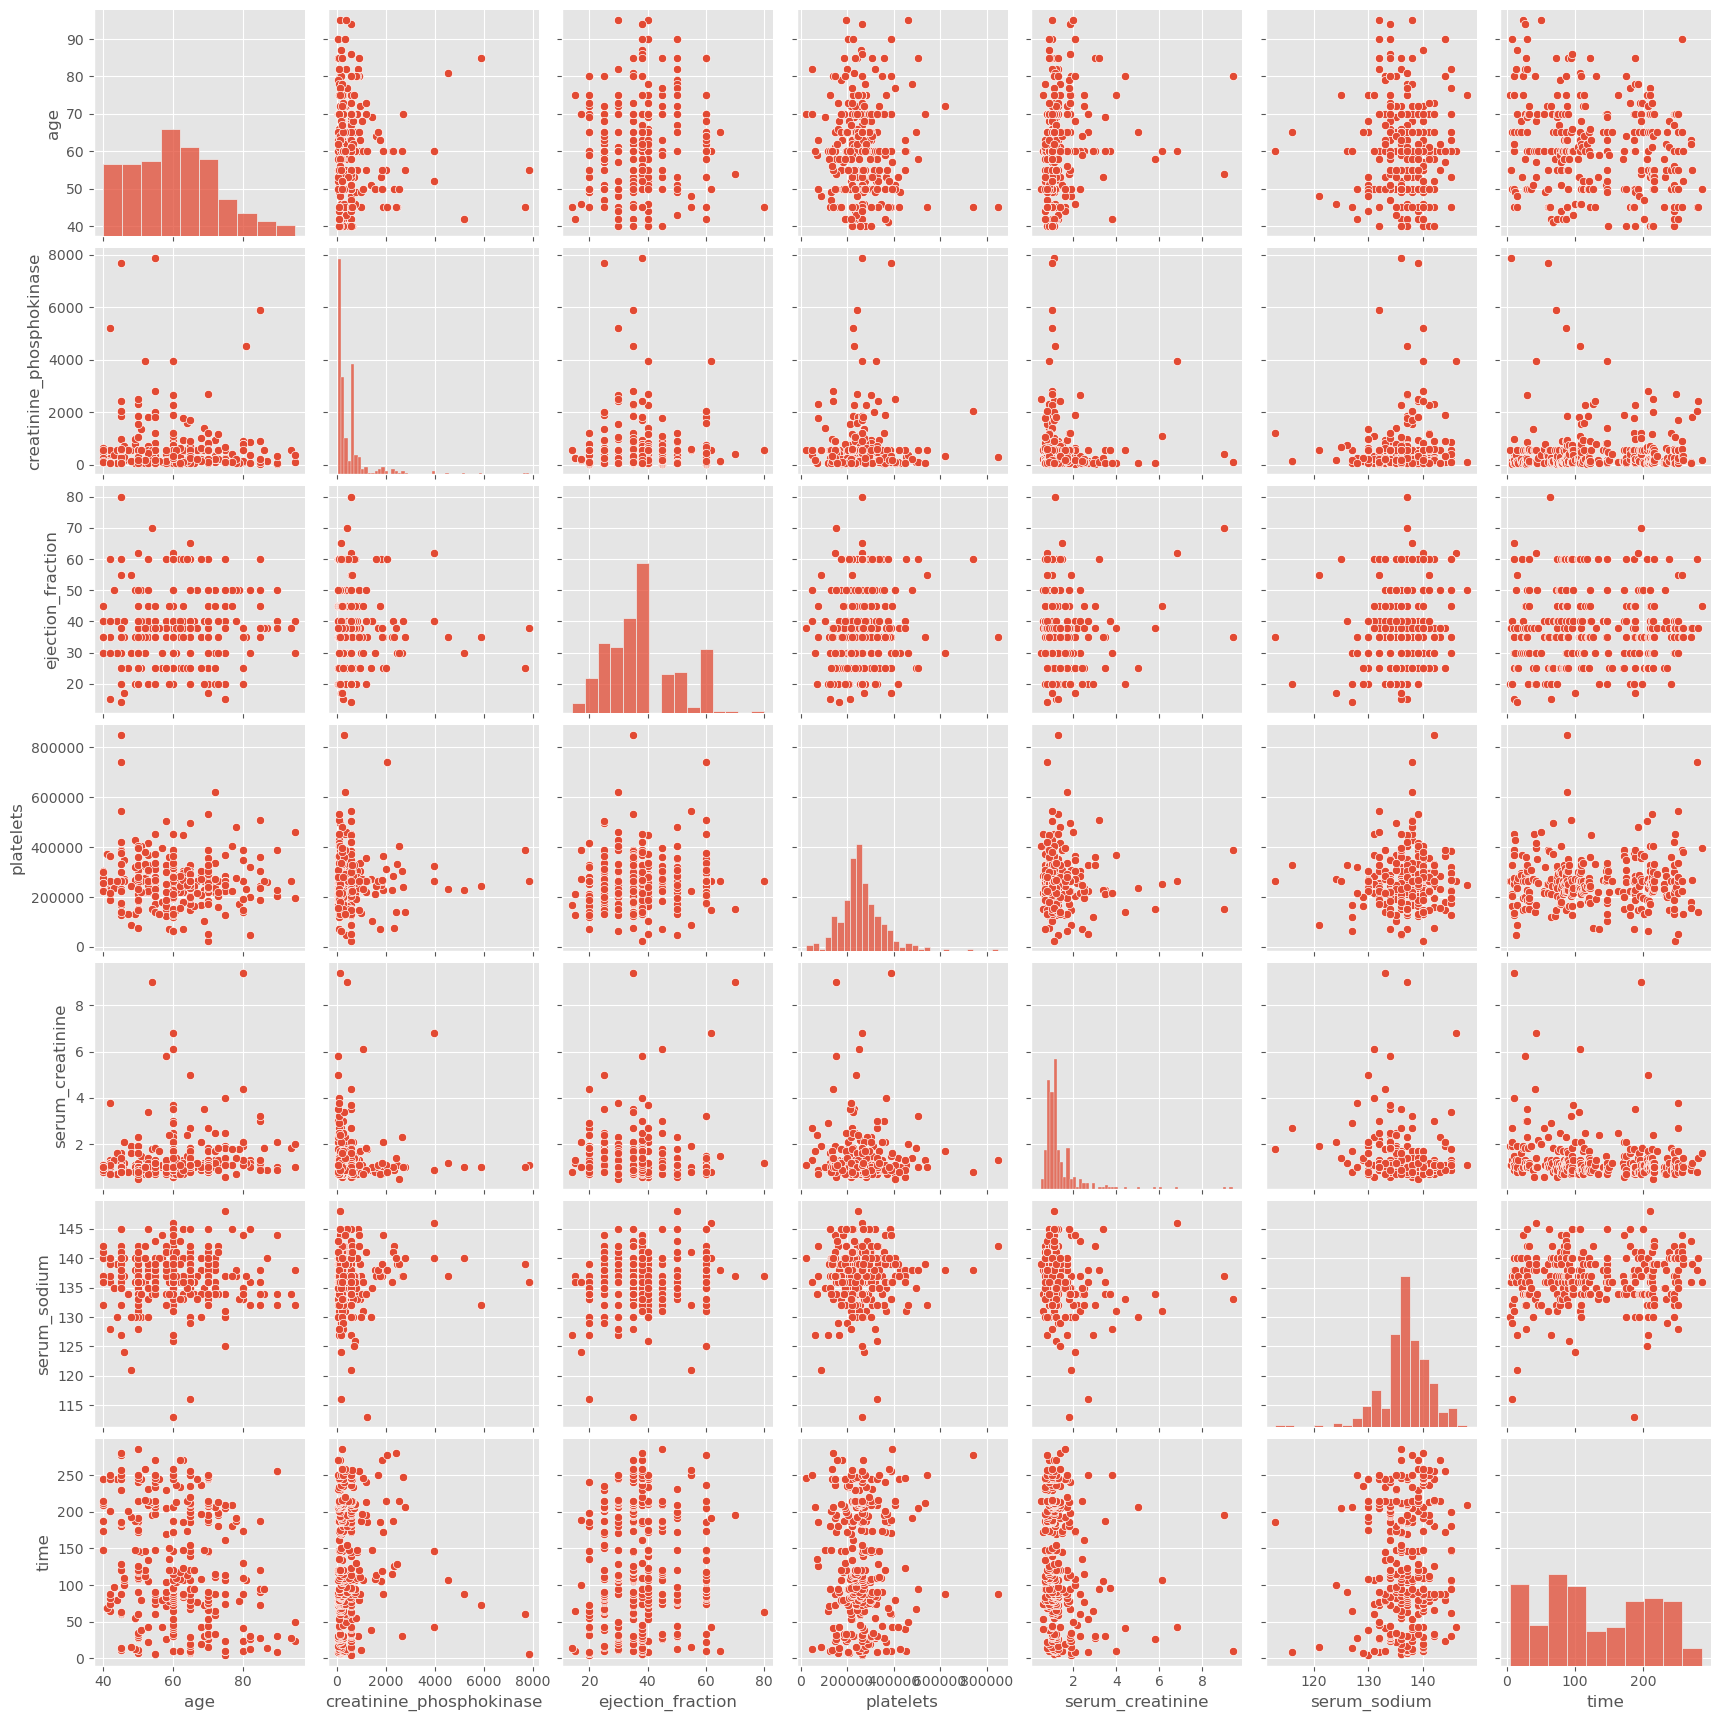

In [25]:
num_data=data.select_dtypes(include=["float64","int64"])
sns.pairplot(num_data)

<Axes: xlabel='age', ylabel='Count'>

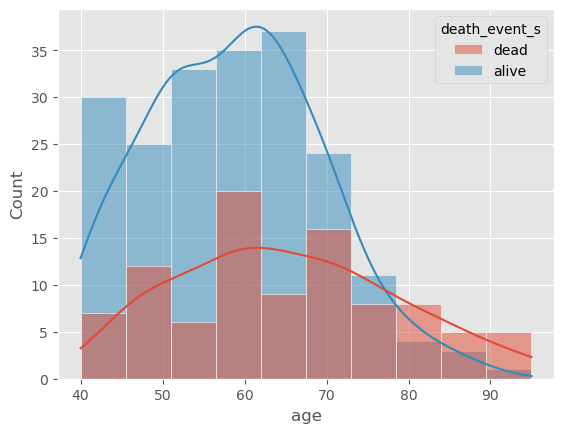

In [ ]:
sns.histplot(data=data,x="age",hue="death_event_s",kde=True) #A parameter is something you pass inside a function to tell it
#hue- Which column to use for color grouping --
#kde- Whether to draw smooth density curve (True/False) --if I had infinite patients, what would the shape of this distribution look like

we just checked if age is a good predictor ...so we watched the death count with age 

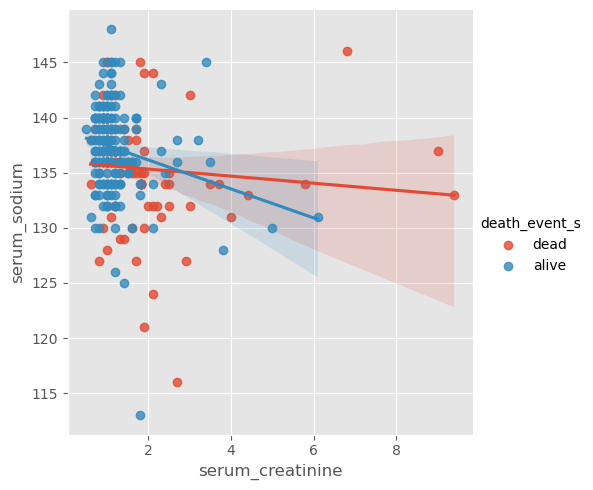

In [27]:
sns.lmplot(data=data,y="serum_sodium",x="serum_creatinine",hue="death_event_s")

the blue line says -for surviving patients, as creatinine goes up, sodium drops noticeably
the red line says -for dead patients, the sodium drop is gentler but extends to much higher creatinine values

what does it mean that both lines start at the same point?
At low creatinine (normal kidney function), both dead and alive patients have similar sodium levels (~136). The difference between groups only emerges as creatinine increases.

the shadded thing shows the confience interval..means in rhat shaded point the line stays


blue shadded is very narrow and tight around the blue line
This means seaborn is saying → "I am very confident this is where the alive line sits"
Why so confident? Because you have ~200 alive patients — lots of data = tight band

 Red Shaded Band
It starts narrow on the left (around creatinine = 0–2)
Then it explodes wide like a fan as it goes right (creatinine = 4, 6, 8, 9)
This means seaborn is saying → "On the left I'm confident, but on the right? I have barely any data — I'm guessing"
Why does it fan out? Because past creatinine = 3, you only have 4–5 red dots — almost no data

thee red band becoming a wide open fan on the right side is actually a WARNING from seaborn telling you:

"Don't trust predictions for patients with creatinine above 3 — you don't have enough dead patients there to draw any reliable conclusions" so the red line could go up tooo.

<Axes: xlabel='sex', ylabel='smoking'>

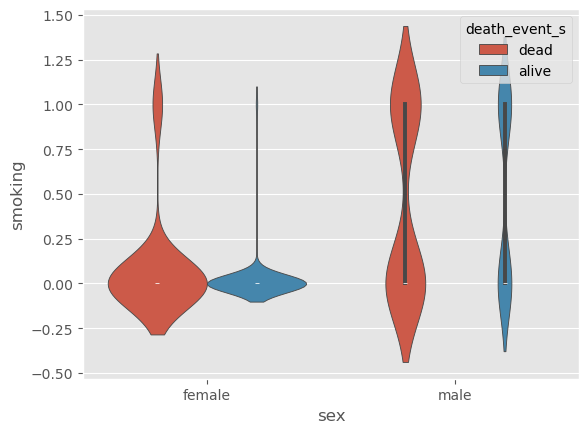

In [28]:
sns.violinplot(data=data, x="sex",y="smoking",hue="death_event_s")

hue= death_event_s (Does this variable help me predict death? )
Red (dead females) → Big wide bulge at 0 → most dead females were non-smokers
Blue (alive females) → Very thin, tiny shape → almost all alive females clustered tightly at 0 → also non-smokers
Conclusion → Almost no females in this dataset smoked at all

well smoking seems to be week predictor

In [29]:
data['sex'] = data['sex'].map({'male': 1, 'female': 0})

correlation=data.iloc[:,:-1].corr()

<Axes: >

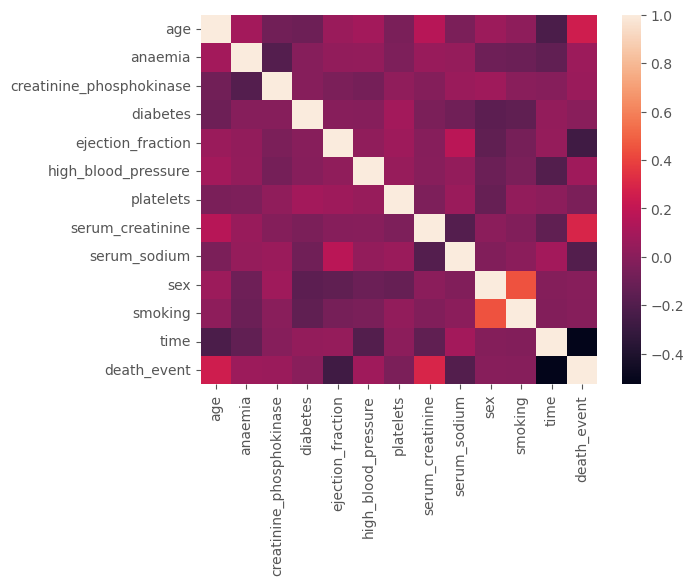

In [30]:
sns.heatmap(correlation)

<Axes: xlabel='death_event', ylabel='serum_creatinine'>

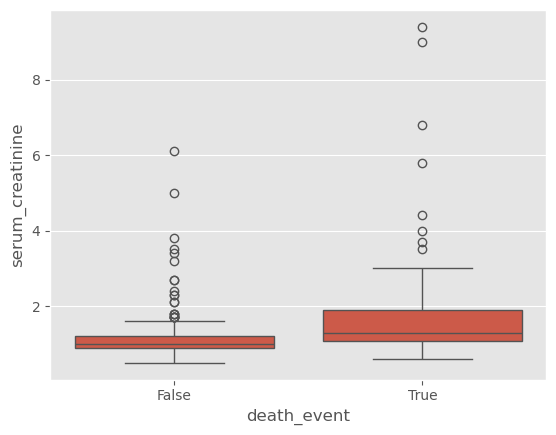

In [31]:
sns.boxplot(data=data ,y ="serum_creatinine",x="death_event")

<Axes: xlabel='death_event', ylabel='ejection_fraction'>

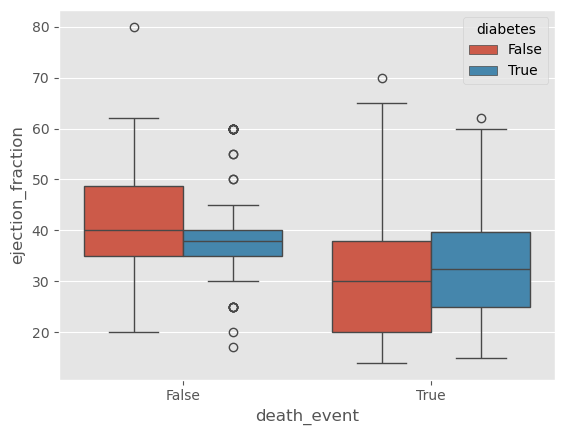

In [32]:
sns.boxplot(data=data, x="death_event",y ="ejection_fraction",hue="diabetes")

 summarization
 
from structurqal point of view the dataset was reduced by removing the duplicates and the null values,8 rows containing null values and seven rows have missing values across all columns
 
in the reasoning step the analysis of the variable data types are adjusted such that they make sense. 7 out of 13 columns are boolean and 6 are numerical, 2 coluns encode the exact inforamtion
differently. one as boolean and one is text
some string processing is needed for ensuring data consistency

potential quesions to choose are
1. are the risk factors predicting whether a person will die or live?
2. Do male have a riskier behaviour than the females with respect to their health?
3. Does age play a role in engaging in riskier health beahvioys like smoking or obesity?